<a href="https://colab.research.google.com/github/YashinSergey/Games-Rating-ML-project/blob/main/Games_Rating_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Предсказание рейтинга настольных игр

Данный проект нацелен на создание модели, которая сможет предсказывать средний рейтинг игры на основе предоставленных характеристик.

Для обучения будет использован датасет. содержащий рейтинг оклло 15 000 игр.

Этапы проекта:

- Исследование и анализ датасета
- Предобработка данных
- Feature Engineering (если необходимо)
- Подбор признаков, их анализ и оценка важности
- Обучение нескольких моделей, их сравнение
- Подбор гиперпараметров
- Выбор лучшей модели и объяснение выбора
- Предсказание на тестовых данных


In [549]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение на train и test
from sklearn.model_selection import train_test_split


# Модели
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Масштабирование
from sklearn.preprocessing import StandardScaler
# подбор гиперпараметров
from sklearn.model_selection import GridSearchCV

# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [475]:
train_df = pd.read_csv('/content/train_data.csv')
test_df = pd.read_csv('/content/test_data.csv')
sample_submition = pd.read_csv('/content/sample_submition.csv')

## 1. Исследование и анализ датасета

In [476]:
train_df.describe()

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Owned Users
count,15247.000000,15256.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15240.000000
mean,108221.590214,1984.144140,2.021236,5.642918,92.801337,9.581766,819.530773,10186.327784,1372.209843
std,98862.566448,211.725679,0.696323,12.551944,607.611378,3.671560,3286.396397,5863.744570,4681.296849
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000
25%,10907.000000,2001.000000,2.000000,4.000000,30.000000,8.000000,55.000000,5103.000000,146.000000
50%,88316.000000,2011.000000,2.000000,4.000000,45.000000,10.000000,119.000000,10171.000000,308.000000
75%,193045.500000,2016.000000,2.000000,6.000000,90.000000,12.000000,379.000000,15280.000000,856.250000
max,331787.000000,2022.000000,10.000000,999.000000,60000.000000,25.000000,102214.000000,20344.000000,155312.000000


In [477]:
# Проверим структуру данных
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  object 
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  object 
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 1.6+ MB


Видны пропуски, неинформатвный признак ID(удалить) и нечисловые типы.

In [478]:
# Исследование признака Name
train_df['Name'].value_counts()

,count
Name,
Robin Hood,6
Cosmic Encounter,4
Gettysburg,4
Saga,4
Coup,3
...,...
Middle-earth Strategy Battle Game: The Lord of the Rings - Battle of Pelennor Fields,1
2019: The ARCTIC,1
Runika and the Six-sided Spellbooks,1


Признак Name обладает высокой кординальностью. Неинформативен. Удалить

Пропуски: 1
Нули(0): 143
Нули(None): 1
Уникальные значения: 164
Самые ранние значения:
 6088    -3500.0
123     -2200.0
15007   -1400.0
14740   -1400.0
15256   -1300.0
15255    -200.0
11343    -100.0
12254       0.0
Name: Year Published, dtype: float64
Самые поздние значения:
 6693     2022.0
11824    2021.0
9627     2021.0
8219     2021.0
6136     2021.0
Name: Year Published, dtype: float64


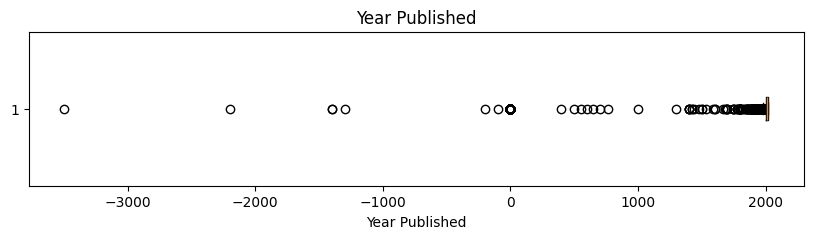

In [479]:
# Исследование признака Year Published
print('Пропуски:', train_df['Year Published'].isna().sum())
print('Нули(0):', (train_df['Year Published'] == 0).sum())
print('Нули(None):', train_df['Year Published'].isna().sum())
print('Уникальные значения:', train_df['Year Published'].nunique())
print('Самые ранние значения:\n', train_df['Year Published'].sort_values().head(8))
print('Самые поздние значения:\n', train_df['Year Published'].sort_values(ascending=False).head(5))

plt.figure(figsize=(10, 2))
plt.boxplot(train_df['Year Published'].dropna(), vert=False)
plt.xlabel('Year Published')
plt.title('Year Published')
plt.show()

Анализ признака Year Published показал наличие нулевых значений, которые не соответствуют реальному году публикации и интерпретируются как пропущенные данные. Кроме того, в датасете присутствуют отрицательные значения года, соответствующие древним настольным играм (например, Go или Senet).   
Заменить нулевые значения NaN, а потом заполнить медианой.
После, стоит заменить Year Published новым признаком Game Age, так как возраст - это более интерпретируемая величина для модели, нежели год выпуска.

In [480]:
# Исследование признака Min Players

# статистика
print('Статистика признака Min Players:')
display(train_df['Min Players'].describe())

# распределение
print('\nРаспределение значений Min Players:')
display(train_df['Min Players'].value_counts().sort_index())

Статистика признака Min Players:


,Min Players
count,15257.000000
mean,2.021236
std,0.696323
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,10.000000



Распределение значений Min Players:


,count
Min Players,
0,33
1,2480
2,10496
3,1803
4,356
5,48
6,14
7,12
8,12


В признаке Min Players обнаружены некорректные значения (0). Игра не может требовать ноль игроков. Заменить на 1 (соответствует минимально возможному количеству игроков)

In [481]:
# Исследование признака Max Players

# статистика
print('Статистика признака Max Players:')
display(train_df['Max Players'].describe())

# распределение
print('\nРаспределение значений Max Players:')
display(train_df['Max Players'].value_counts().sort_index())

# проверка количества некорректных значений (игра не может иметь 0 игроков)
print('\nКоличество записей с Max Players = 0:', (train_df['Max Players'] == 0).sum())

# считаем выбросы (слишком большое количество игроков)
print('\nКоличество записей с Max Players > 20:',
      (train_df['Max Players'] > 20).sum())

Статистика признака Max Players:


,Max Players
count,15257.000000
mean,5.642918
std,12.551944
min,0.000000
25%,4.000000
50%,4.000000
75%,6.000000
max,999.000000



Распределение значений Max Players:


,count
Max Players,
0,113
1,241
2,3062
3,198
4,4783
5,2113
6,2793
7,233
8,853



Количество записей с Max Players = 0: 113

Количество записей с Max Players > 20: 195


Значения Max Players = 0 считаем ошибочными, а значения Max Players > 20 — выбросами. Заменим значения медианой по признаку Mechanics с учетом его мультикатегориальности.

In [482]:
# Исследование признака Play Time

# статистика
print('Статистика признака Play Time:')
display(train_df['Play Time'].describe())

# распределение
print('\nРаспределение значений Play Time:')
display(train_df['Play Time'].value_counts().sort_index())

# проверка некорректных значений (игра не может длиться 0 минут)
print('\nКоличество записей с Play Time = 0:',
      (train_df['Play Time'] == 0).sum())

# проверка выбросов (слишком большая длительность игры)
print('Количество записей с Play Time > 600:',
      (train_df['Play Time'] > 600).sum())

Статистика признака Play Time:


,Play Time
count,15257.000000
mean,92.801337
std,607.611378
min,0.000000
25%,30.000000
50%,45.000000
75%,90.000000
max,60000.000000



Распределение значений Play Time:


,count
Play Time,
0,408
1,13
2,7
3,1
4,1
...,...
10000,1
12000,2
17280,1



Количество записей с Play Time = 0: 408
Количество записей с Play Time > 600: 122


В признаке Play Time обнаружены некорректные значения (0) — 408 записей. Игра не может длиться 0 минут. Заменить эти значения медианой по признаку Mechanics с учетом его мультикатегориальности. Также обнаружены выбросы (Play Time > 600) — 122 записи. Ограничить верхним порогом 600 минут.

In [483]:
# Исследование признака Min Age

# статистика
print('Статистика признака Min Age:')
display(train_df['Min Age'].describe())

# распределение
print('\nРаспределение значений Min Age:')
display(train_df['Min Age'].value_counts().sort_index())

# проверка некорректных значений (возраст не может быть 0)
print('\nКоличество записей с Min Age = 0:', (train_df['Min Age'] == 0).sum())

# проверка выбросов (слишком большой минимальный возраст)
print('Количество записей с Min Age > 21:', (train_df['Min Age'] > 21).sum())

Статистика признака Min Age:


,Min Age
count,15257.000000
mean,9.581766
std,3.671560
min,0.000000
25%,8.000000
50%,10.000000
75%,12.000000
max,25.000000



Распределение значений Min Age:


,count
Min Age,
0,976
1,2
2,11
3,80
4,198
5,326
6,664
7,601
8,3060



Количество записей с Min Age = 0: 976
Количество записей с Min Age > 21: 1


В признаке Min Age обнаружены некорректные значения (0) — 976 записей. Минимальный возраст не может быть равен 0. Заменить на 1 (минимально возможный возраст). Также обнаружен выброс Min Age > 21 — 1 запись. Ограничить верхним порогом 21.

In [484]:
# Исследование признака Users Rated

# статистика
print('Статистика признака Users Rated:')
display(train_df['Users Rated'].describe())

# распределение
print('\nРаспределение значений Users Rated:')
display(train_df['Users Rated'].value_counts().sort_index())

# проверка некорректных значений
print('\nКоличество записей с Users Rated < 0:', (train_df['Users Rated'] < 0).sum())

Статистика признака Users Rated:


,Users Rated
count,15257.000000
mean,819.530773
std,3286.396397
min,30.000000
25%,55.000000
50%,119.000000
75%,379.000000
max,102214.000000



Распределение значений Users Rated:


,count
Users Rated,
30,209
31,203
32,180
33,198
34,195
...,...
63498,1
64864,1
71611,1



Количество записей с Users Rated < 0: 0


В признаке Users Rated некорректных значений не обнаружено. Отрицательные значения отсутствуют

In [485]:
# Исследование признака BGG Rank

# статистика
print('Статистика признака BGG Rank:')
display(train_df['BGG Rank'].describe())

# распределение
print('\nРаспределение значений BGG Rank:')
display(train_df['BGG Rank'].value_counts().sort_index())

# проверка некорректных значений
print('\nКоличество записей с BGG Rank <= 0:', (train_df['BGG Rank'] <= 0).sum())

Статистика признака BGG Rank:


,BGG Rank
count,15257.000000
mean,10186.327784
std,5863.744570
min,1.000000
25%,5103.000000
50%,10171.000000
75%,15280.000000
max,20344.000000



Распределение значений BGG Rank:


,count
BGG Rank,
1,1
3,1
4,1
5,1
6,1
...,...
20339,1
20340,1
20342,1



Количество записей с BGG Rank <= 0: 0


В признаке BGG Rank некорректные значения не обнаружены. Значения ≤ 0 отсутствуют.

In [486]:
# Исследование признака Complexity Average

# приведение к числовому типу
complexity = pd.to_numeric(train_df['Complexity Average'], errors='coerce')

# статистика
print('Статистика признака Complexity Average:')
display(complexity.describe())

# распределение
print('\nРаспределение значений Complexity Average:')
display(complexity.value_counts().sort_index())

# проверка некорректных значений
print('\nКоличество записей с Complexity Average < 0:', (complexity < 0).sum())
print('Количество записей с Complexity Average > 5:', (complexity > 5).sum())
print('Количество записей с Complexity Average == 0:', (complexity == 0).sum())

Статистика признака Complexity Average:


,Complexity Average
count,3655.000000
mean,1.474419
std,0.840830
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5.000000



Распределение значений Complexity Average:


,count
Complexity Average,
0.0,329
1.0,1723
2.0,1189
3.0,369
4.0,44
5.0,1



Количество записей с Complexity Average < 0: 0
Количество записей с Complexity Average > 5: 0
Количество записей с Complexity Average == 0: 329


В признаке Complexity Average обнаружены некорректные значения 0 (сложность на BGG измеряется по шкале 1–5).
Заменить значения 0 на медиану признака.

In [487]:
# Исследование признака Owned Users

# статистика
print('Статистика признака Owned Users:')
display(train_df['Owned Users'].describe())

# распределение
print('\nРаспределение значений Owned Users:')
display(train_df['Owned Users'].value_counts().sort_index())

# проверка некорректных значений
print('\nКоличество записей с Owned Users < 0:', (train_df['Owned Users'] < 0).sum())

# проверка пропусков
print('Количество NaN в Owned Users:', train_df['Owned Users'].isna().sum())

Статистика признака Owned Users:


,Owned Users
count,15240.000000
mean,1372.209843
std,4681.296849
min,0.000000
25%,146.000000
50%,308.000000
75%,856.250000
max,155312.000000



Распределение значений Owned Users:


,count
Owned Users,
0.0,1
3.0,4
4.0,1
5.0,3
6.0,7
...,...
92896.0,1
94343.0,1
97463.0,1



Количество записей с Owned Users < 0: 0
Количество NaN в Owned Users: 17


В признаке Owned Users обнаружены пропущенные значения (17 NaN). Количество владельцев не может быть отрицательным, но может быть неизвестным.
Заменить NaN на медиану признака

In [488]:
# Исследование признака Mechanics

# количество пропусков
print('Количество NaN в Mechanics:', train_df['Mechanics'].isna().sum())

# количество уникальных значений
print('\nКоличество уникальных значений Mechanics:', train_df['Mechanics'].nunique())

# проверка мультикатегориальности
mechanics_clean = train_df['Mechanics'].dropna().str.replace('/', ',', regex=False)

multi_mechanics = mechanics_clean.str.contains(',')
print('Количество записей с несколькими механиками:', multi_mechanics.sum())

# распределение количества механик в записи
mechanics_count = mechanics_clean.str.split(',').apply(
    lambda values: len([value.strip() for value in values if value.strip() != ''])
)

print('\nРаспределение количества механик в игре:')
display(mechanics_count.value_counts().sort_index())

Количество NaN в Mechanics: 1200

Количество уникальных значений Mechanics: 5898
Количество записей с несколькими механиками: 11101

Распределение количества механик в игре:


,count
Mechanics,
1,2956
2,3274
3,2680
4,1878
5,1217
6,703
7,488
8,280
9,210


В признаке Mechanics обнаружена мультикатегориальность (несколько механик у одной игры) и пропущенные значения (1200). Также используются два разделителя ("," и "/"). Перед кодированием необходимо привести разделители к одному ("/" -> ","), пропуски заменить на "Unknown", после чего выполнить multi-one-hot encoding.

In [489]:
# Исследование признака Domains

# количество пропусков
print('Количество NaN в Domains:', train_df['Domains'].isna().sum())

# количество уникальных значений
print('\nКоличество уникальных значений Domains:', train_df['Domains'].nunique())

# проверка мультикатегориальности
multi_domains = train_df['Domains'].dropna().str.contains(',')
print('Количество записей с несколькими доменами:', multi_domains.sum())

# распределение количества доменов в игре
domains_count = train_df['Domains'].dropna().str.split(',').apply(
    lambda values: len([value.strip() for value in values if value.strip() != ''])
)

print('\nРаспределение количества доменов в игре:')
display(domains_count.value_counts().sort_index())

Количество NaN в Domains: 7649

Количество уникальных значений Domains: 39
Количество записей с несколькими доменами: 1106

Распределение количества доменов в игре:


,count
Domains,
1,6502
2,1093
3,13


В признаке Domains обнаружена мультикатегориальность (одна игра может принадлежать нескольким доменам) и большое количество пропусков (7649 NaN). Пропуски заменить на "Unknown", затем выполнить multi-one-hot encoding по разделителю ",".

Статистика признака Rating Average:


,Rating Average
count,15257
unique,610
top,"6,50"
freq,89



Распределение значений Rating Average:


,count
Rating Average,
"1,05",1
"1,10",1
"1,32",1
"1,43",1
"1,54",1
...,...
"9,31",1
"9,34",1
"9,43",1


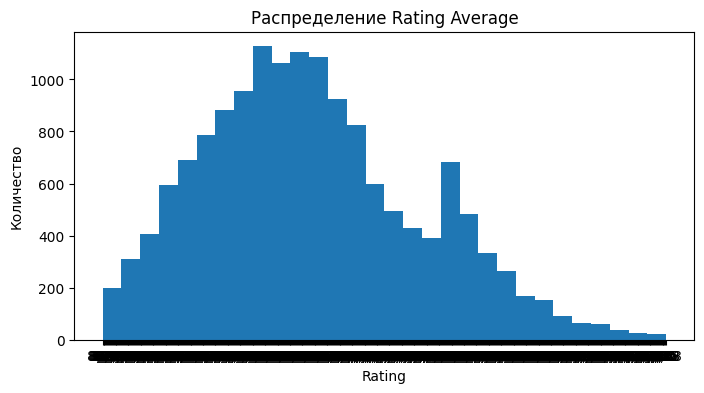

In [490]:
# Исследование целевой переменной Rating Average

# статистика
print('Статистика признака Rating Average:')
display(train_df['Rating Average'].describe())

# распределение значений
print('\nРаспределение значений Rating Average:')
display(train_df['Rating Average'].value_counts().sort_index())

# визуализация распределения
plt.figure(figsize=(8,4))
plt.hist(train_df['Rating Average'], bins=30)
plt.title('Распределение Rating Average')
plt.xlabel('Rating')
plt.ylabel('Количество')
plt.show()

Целевая переменная Rating Average представлена строками с десятичным разделителем ",". Необходимо заменить "," на "." и привести признак к числовому типу float. Распределение значений близко к нормальному, значения находятся в допустимом диапазоне рейтинга BGG (примерно 1–10).

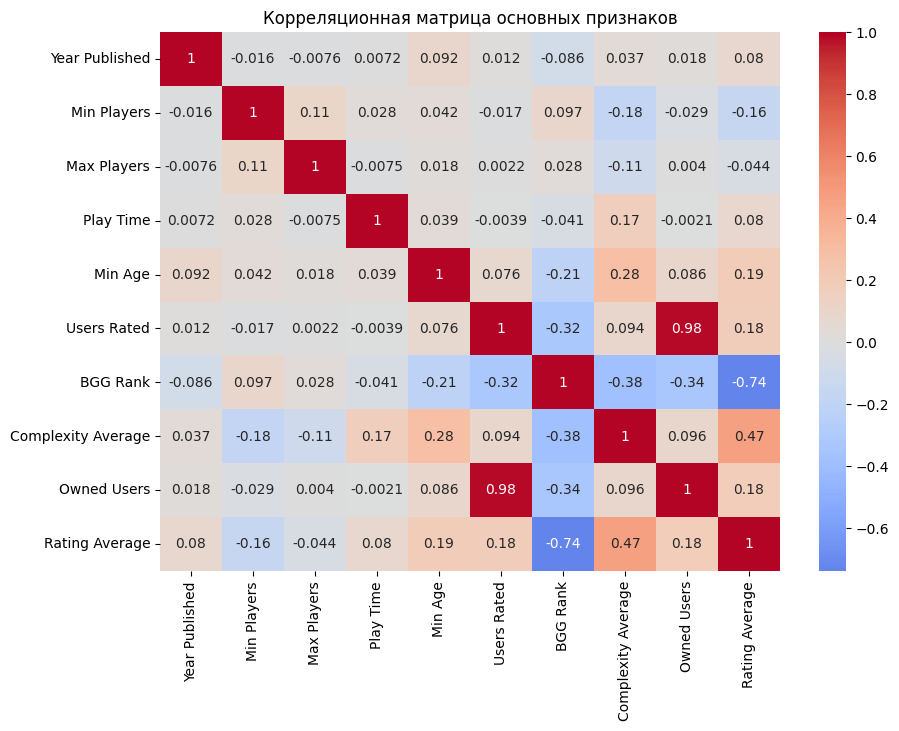

In [491]:
# корреляционная матрица основных признаков (train_df)
base_features = [
    'Year Published',
    'Min Players',
    'Max Players',
    'Play Time',
    'Min Age',
    'Users Rated',
    'BGG Rank',
    'Complexity Average',
    'Owned Users',
    'Rating Average'
]

corr_df = train_df[base_features].copy()

# приводим признаки с запятой к float
corr_df['Complexity Average'] = corr_df['Complexity Average'].str.replace(',', '.', regex=False).astype(float)
corr_df['Rating Average'] = corr_df['Rating Average'].str.replace(',', '.', regex=False).astype(float)

corr_matrix = corr_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Корреляционная матрица основных признаков')
plt.show()

Сильная линейная взаимосвязь между признаками Users Rated и Owned Users (0.98). Это указывает на мультиколлинеарность. Оба признака отражают популярность игры и несут практически одинаковую информацию.   
- Удалить Owned Users

Высокая отрицательная корреляция между признаком BGG Rank и целевой переменной Rating Average (-0.74).   
- Удалить BGG Rank

## 2. Предобработка данных

In [492]:
# processed копии
train_processed = train_df.copy()
test_processed = test_df.copy()

In [493]:
# предобработка признаков ID, Name, Owned Users и BGG Rank
def preprocess_drop_id_name(df):
    df = df.copy()

    # удаляем неинформативные признаки
    df = df.drop(columns=['ID', 'Name', 'Owned Users', 'BGG Rank'], errors='ignore')
    return df

In [494]:
train_processed = preprocess_drop_id_name(train_processed)
test_processed = preprocess_drop_id_name(test_processed)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [495]:
# функция предобработки признака Year Published
def preprocess_year_published(df, fill_value=None):
    df = df.copy()
    # приводим к числовому типу
    df['Year Published'] = pd.to_numeric(df['Year Published'], errors='coerce')
    # 0 считаем ошибочным значением
    df.loc[df['Year Published'] == 0, 'Year Published'] = pd.NA

    # если медиана не передана — считаем по текущему df
    if fill_value is None:
        fill_value = df['Year Published'].median()
    # заполняем пропуски
    df['Year Published'] = df['Year Published'].fillna(fill_value)
    return df, fill_value

In [496]:
# предобработка признака Year Published
train_processed, year_published_median = preprocess_year_published(train_processed)
test_processed, _ = preprocess_year_published(test_processed, fill_value=year_published_median)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [497]:
# функция предобработки признака Min Players
def preprocess_min_players(df, fill_value=1):
    df = df.copy()
    # 0 считаем ошибочным значением и заменяем на минимально допустимое
    df.loc[df['Min Players'] == 0, 'Min Players'] = fill_value
    return df

In [498]:
# предобработка признака Min Players
train_processed = preprocess_min_players(train_processed)
test_processed = preprocess_min_players(test_processed)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [499]:
# функция предобработки признака Min Age
def preprocess_min_age(df, min_value=1, max_value=21):
    df = df.copy()
    # 0 заменяем на минимально допустимый возраст
    df.loc[df['Min Age'] == 0, 'Min Age'] = min_value
    # слишком большие значения ограничиваем верхним порогом
    df.loc[df['Min Age'] > max_value, 'Min Age'] = max_value
    return df

In [500]:
# предобработка признака Min Age
train_processed = preprocess_min_age(train_processed)
test_processed = preprocess_min_age(test_processed)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [501]:
# функция предобработки признака Complexity Average
def preprocess_complexity_average(df, fill_value=None):
    df = df.copy()

    # приводим к строке, заменяем запятую на точку и переводим в float
    df['Complexity Average'] = (
        df['Complexity Average']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

    # 0 считаем ошибочным значением
    df.loc[df['Complexity Average'] == 0, 'Complexity Average'] = pd.NA

    # если значение заполнения не передано — считаем медиану
    if fill_value is None:
        fill_value = df['Complexity Average'].median()

    # заполняем пропуски
    df['Complexity Average'] = df['Complexity Average'].fillna(fill_value)
    return df, fill_value

In [502]:
# предобработка признака Complexity Average
train_processed, complexity_median = preprocess_complexity_average(train_processed)
test_processed, _ = preprocess_complexity_average(test_processed, complexity_median)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [503]:
# функция предобработки признака Mechanics
def preprocess_mechanics(df, fill_value='Unknown'):
    df = df.copy()

    # заполняем пропуски
    df['Mechanics'] = df['Mechanics'].fillna(fill_value)

    # приводим разделители к одному виду
    df['Mechanics'] = df['Mechanics'].str.replace('/', ',', regex=False)

    # убираем лишние пробелы вокруг механик
    df['Mechanics'] = df['Mechanics'].apply(
        lambda value: ', '.join(
            [item.strip() for item in value.split(',') if item.strip() != '']
        )
    )
    return df

In [504]:
# предобработка признака Mechanics
train_processed = preprocess_mechanics(train_processed)
test_processed = preprocess_mechanics(test_processed)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [505]:
# функция предобработки признака Max Players
def preprocess_max_players(df, mechanic_means=None, default_value=None, max_value=20):
    df = df.copy()

    # если статистики не переданы, считаем их по текущему датафрейму
    if mechanic_means is None or default_value is None:
        valid_rows = df[(df['Max Players'] > 0) & (df['Max Players'] <= max_value)].copy()

        # разворачиваем список механик в отдельные строки
        exploded = valid_rows.assign(
            Mechanics=valid_rows['Mechanics'].str.split(', ')
        ).explode('Mechanics')

        # считаем среднее значение Max Players по каждой механике
        mechanic_means = exploded.groupby('Mechanics')['Max Players'].mean()

        # общее среднее используем как запасной вариант
        default_value = valid_rows['Max Players'].mean()

    # маска для ошибочных значений и выбросов
    invalid_mask = (df['Max Players'] == 0) | (df['Max Players'] > max_value)

    # заменяем ошибочные значения средним по механикам игры
    df.loc[invalid_mask, 'Max Players'] = df.loc[invalid_mask, 'Mechanics'].apply(
        lambda value: round(
            pd.Series([mechanic_means.get(item, default_value) for item in value.split(', ')]).mean()
        )
    )

    # на всякий случай ограничиваем верхним порогом
    df.loc[df['Max Players'] > max_value, 'Max Players'] = max_value
    return df, mechanic_means, default_value

In [506]:
# предобработка признака Max Players
train_processed, max_players_means, max_players_default = preprocess_max_players(train_processed)
test_processed, _, _ = preprocess_max_players(
    test_processed,
    mechanic_means=max_players_means,
    default_value=max_players_default
)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [507]:
# функция предобработки признака Play Time
def preprocess_play_time(df, mechanic_means=None, default_value=None, max_value=600):
    df = df.copy()

    # если статистики не переданы, считаем их по текущему датафрейму
    if mechanic_means is None or default_value is None:
        valid_rows = df[(df['Play Time'] > 0) & (df['Play Time'] <= max_value)].copy()

        # разворачиваем список механик в отдельные строки
        exploded = valid_rows.assign(
            Mechanics=valid_rows['Mechanics'].str.split(', ')
        ).explode('Mechanics')

        # считаем среднее значение Play Time по каждой механике
        mechanic_means = exploded.groupby('Mechanics')['Play Time'].mean()

        # общее среднее используем как запасной вариант
        default_value = valid_rows['Play Time'].mean()

    # маска для ошибочных значений
    zero_mask = df['Play Time'] == 0

    # нулевые значения заменяем средним по механикам игры
    df.loc[zero_mask, 'Play Time'] = df.loc[zero_mask, 'Mechanics'].apply(
        lambda value: round(
            pd.Series([mechanic_means.get(item, default_value) for item in value.split(', ')]).mean()
        )
    )

    # выбросы ограничиваем верхним порогом
    df.loc[df['Play Time'] > max_value, 'Play Time'] = max_value
    return df, mechanic_means, default_value

In [508]:
# предобработка признака Play Time
train_processed, play_time_means, play_time_default = preprocess_play_time(train_processed)
test_processed, _, _ = preprocess_play_time(
    test_processed,
    mechanic_means=play_time_means,
    default_value=play_time_default
)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [509]:
# функция предобработки признака Domains
def preprocess_domains(df, fill_value='Unknown'):
    df = df.copy()

    # заполняем пропуски
    df['Domains'] = df['Domains'].fillna(fill_value)

    # убираем лишние пробелы вокруг доменов
    df['Domains'] = df['Domains'].apply(
        lambda value: ', '.join(
            [item.strip() for item in value.split(',') if item.strip() != '']
        )
    )
    return df

In [510]:
# предобработка признака Domains
train_processed = preprocess_domains(train_processed)
test_processed = preprocess_domains(test_processed)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [511]:
# функция предобработки целевой переменной Rating Average
def preprocess_rating_average(df):
    df = df.copy()

    # заменяем запятую на точку и приводим к числовому типу
    df['Rating Average'] = (
        df['Rating Average']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

    return df

In [512]:
# предобработка целевой переменной Rating Average
train_processed = preprocess_rating_average(train_processed)

In [513]:
# проверка результатов предобработки

display(train_processed.info())
display(test_processed.info())

# проверка проблемных значений
checks = {
    'Min Players = 0': (train_processed['Min Players'] == 0).sum(),
    'Max Players = 0': (train_processed['Max Players'] == 0).sum(),
    'Max Players > 20': (train_processed['Max Players'] > 20).sum(),
    'Play Time = 0': (train_processed['Play Time'] == 0).sum(),
    'Play Time > 600': (train_processed['Play Time'] > 600).sum(),
    'Min Age = 0': (train_processed['Min Age'] == 0).sum(),
    'Min Age > 21': (train_processed['Min Age'] > 21).sum(),
    'Complexity Average = 0': (train_processed['Complexity Average'] == 0).sum()
}

display(pd.Series(checks, name='Количество проблемных значений'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year Published      15257 non-null  float64
 1   Min Players         15257 non-null  int64  
 2   Max Players         15257 non-null  int64  
 3   Play Time           15257 non-null  int64  
 4   Min Age             15257 non-null  int64  
 5   Users Rated         15257 non-null  int64  
 6   Rating Average      15257 non-null  float64
 7   Complexity Average  15257 non-null  float64
 8   Mechanics           15257 non-null  object 
 9   Domains             15257 non-null  object 
dtypes: float64(3), int64(5), object(2)
memory usage: 1.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year Published      5086 non-null   float64
 1   Min Players         5086 non-null   int64  
 2   Max Players         5086 non-null   int64  
 3   Play Time           5086 non-null   int64  
 4   Min Age             5086 non-null   int64  
 5   Users Rated         5086 non-null   int64  
 6   Complexity Average  5086 non-null   float64
 7   Mechanics           5086 non-null   object 
 8   Domains             5086 non-null   object 
dtypes: float64(2), int64(5), object(2)
memory usage: 357.7+ KB


None

,Количество проблемных значений
Min Players = 0,0
Max Players = 0,0
Max Players > 20,0
Play Time = 0,0
Play Time > 600,0
Min Age = 0,0
Min Age > 21,0
Complexity Average = 0,0


На этапе предобработки данных были удалены признаки ID, Name, Owned Users и BGG Rank и исправлены некорректные значения в признаках Min Players, Max Players, Play Time и Min Age. Значения Max Players = 0 и Max Players > 20, а также Play Time = 0 были заменены средними значениями по признаку Mechanics. Выбросы Play Time > 600 ограничены верхним порогом 600. В признаке Complexity Average значения 0 заменены медианой, а строки с десятичной запятой приведены к числовому формату. Признаки Mechanics и Domains очищены от пропусков и приведены к единому формату. Также удалены неинформативные признаки ID и Name. В результате датасет не содержит пропусков и некорректных значений и готов к этапу feature engineering.

## 3. Feature Engineering

In [514]:
# encoding-функция признака Game Age
def create_game_age(df, current_year):
    df = df.copy()
    # создаем признак возраста игры
    df['Game Age'] = current_year - df['Year Published']
    # удаляем исходный признак года публикации
    df = df.drop(columns=['Year Published'])
    return df

In [515]:
# encoding признака Game Age
train_processed = create_game_age(train_processed, current_year=2026)
test_processed = create_game_age(test_processed, current_year=2026)
print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 10)
test_processed shape: (5086, 9)


In [516]:
# encoding-функция признака Mechanics
def encode_mechanics(df, mechanics_columns=None):
    df = df.copy()
    mechanics_dummies = df['Mechanics'].str.get_dummies(sep=', ')

    if mechanics_columns is None:
        mechanics_columns = mechanics_dummies.columns
    else:
        mechanics_dummies = mechanics_dummies.reindex(columns=mechanics_columns, fill_value=0)

    mechanics_dummies = mechanics_dummies.add_prefix('mech_')
    df = pd.concat([df.drop(columns=['Mechanics']), mechanics_dummies], axis=1)
    return df, mechanics_columns

In [517]:
# encoding признака Mechanics
train_processed, mechanics_features = encode_mechanics(train_processed)

test_processed, _ = encode_mechanics(
    test_processed,
    mechanics_columns=mechanics_features
)

print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 204)
test_processed shape: (5086, 203)


In [518]:
# encoding-функция признака Domains
def encode_domains(df, domains_columns=None):
    df = df.copy()
    domains_dummies = df['Domains'].str.get_dummies(sep=', ')

    if domains_columns is None:
        domains_columns = domains_dummies.columns
    else:
        domains_dummies = domains_dummies.reindex(columns=domains_columns, fill_value=0)

    domains_dummies = domains_dummies.add_prefix('dom_')
    df = pd.concat([df.drop(columns=['Domains']), domains_dummies], axis=1)
    return df, domains_columns

In [519]:
# encoding признака Domains
train_processed, domains_features = encode_domains(train_processed)
test_processed, _ = encode_domains(
    test_processed,
    domains_columns=domains_features
)

print('train_processed shape:', train_processed.shape)
print('test_processed shape:', test_processed.shape)

train_processed shape: (15257, 212)
test_processed shape: (5086, 211)


In [526]:
# проверка структуры датасетов после feature engineering и encoding
train_processed.info()
print()

print("train_processed shape:", train_processed.shape)
print("test_processed shape:", test_processed.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Columns: 212 entries, Min Players to dom_Wargames
dtypes: float64(3), int64(209)
memory usage: 24.7 MB

train_processed shape: (15257, 212)
test_processed shape: (5086, 211)


In [522]:
train_processed.head(3)

,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,Complexity Average,Game Age,mech_Acting,mech_Action,...,mech_Zone of Control,dom_Abstract Games,dom_Children's Games,dom_Customizable Games,dom_Family Games,dom_Party Games,dom_Strategy Games,dom_Thematic Games,dom_Unknown,dom_Wargames
0,1,4,120,14,42055,8.79,3.86,9.0,0,0,...,0,0,0,0,0,0,1,1,0,0
1,2,4,120,14,19217,8.66,3.91,8.0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1,5,120,12,64864,8.43,3.24,10.0,0,0,...,0,0,0,0,0,0,1,0,0,0


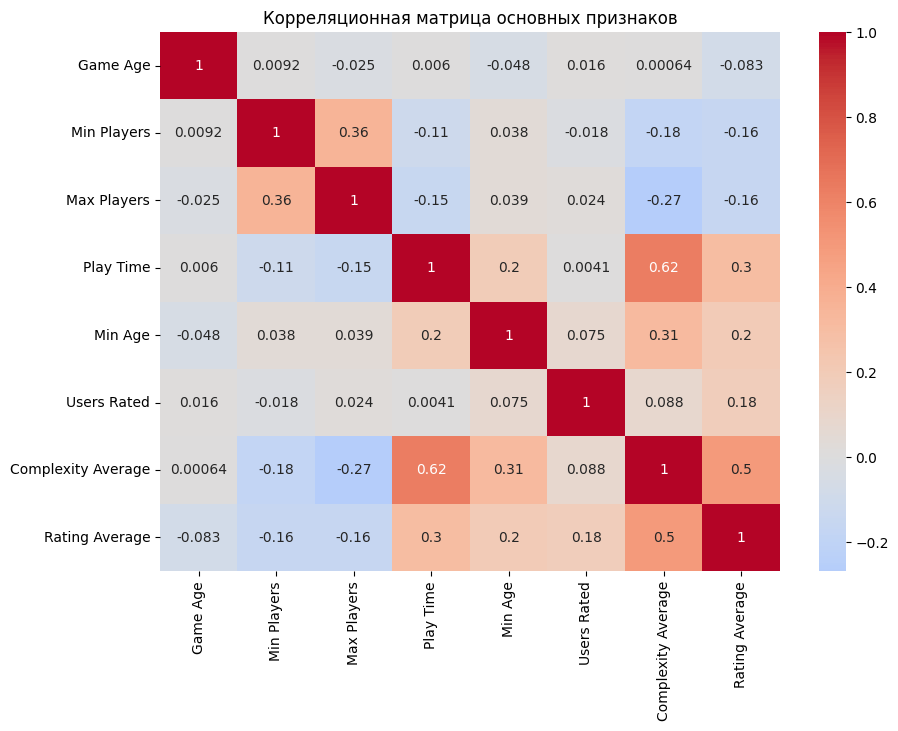

In [521]:
# корреляционная матрица основных признаков
base_features = [
    'Game Age',
    'Min Players',
    'Max Players',
    'Play Time',
    'Min Age',
    'Users Rated',
    'Complexity Average',
    'Rating Average'
]

corr_matrix = train_processed[base_features].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Корреляционная матрица основных признаков')
plt.show()

На этапе feature engineering был создан новый признак Game Age, отражающий возраст игры. Он вычислен как разница между текущим годом и годом публикации. Признак Year Published был удалён.

Мультикатегориальные признаки Mechanics и Domains были закодированы методом multi-hot encoding. Для каждой механики и домена были созданы бинарные признаки. После кодирования исходные признаки Mechanics и Domains были удалены.

В результате все признаки датасета имеют числовой формат и могут быть использованы для обучения.

## 4. Обучение моделей

In [532]:
# разделение на матрицу признаков и целевую переменную
X_train = train_processed.drop(columns=['Rating Average'])
y_train = train_processed['Rating Average']

# матрица признаков тестового датасета
X_test = test_processed.copy()

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X shape: (15257, 211)
y shape: (15257,)
X_test shape: (5086, 211)


In [533]:
# разделение на тренировочную и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (12205, 211)
X_val shape: (3052, 211)
y_train shape: (12205,)
y_val shape: (3052,)


In [553]:
# стандартизация признаков
scaler = StandardScaler()

# train
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# test
X_test_scaled= scaler.fit_transform(X_test)

In [543]:
# обучение модели
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# предсказания
y_train_pred = linear_model.predict(X_train_scaled)
y_val_pred = linear_model.predict(X_val_scaled)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# вывод результатов
print('Linear Regression')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

Linear Regression

Метрики на train:
MAE:  0.5494
RMSE: 0.7252
R2:   0.3946

Метрики на validation:
MAE:  0.5485
RMSE: 0.7454
R2:   0.3890


Значение коэффициента детерминации **R²** на валидационной выборке составило **0.389**, что означает, что модель объясняет около **39% дисперсии целевой переменной**. Полученный результат можно рассматривать как базовый уровень качества, с которым далее будут сравниваться более сложные модели.

In [540]:
# обучение модели
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# предсказания
y_train_pred = knn_model.predict(X_train_scaled)
y_val_pred = knn_model.predict(X_val_scaled)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# вывод результатов
print('KNN Regression')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

KNN Regression

Метрики на train:
MAE:  0.4939
RMSE: 0.6441
R2:   0.5224

Метрики на validation:
MAE:  0.6051
RMSE: 0.8110
R2:   0.2768


**KNN Regression** показывает заметно лучшее качество на обучающей выборке по сравнению с Linear Regression (R² = 0.52), однако на валидационной выборке качество существенно снизилось (R² = 0.28). Это указывает на переобучение модели. В текущей конфигурации KNN показывает более слабый результат по сравнению с Linear Regression.

In [542]:
# обучение модели
svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

# предсказания
y_train_pred = svr_model.predict(X_train_scaled)
y_val_pred = svr_model.predict(X_val_scaled)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# вывод результатов
print('SVR')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

SVR

Метрики на train:
MAE:  0.4515
RMSE: 0.6399
R2:   0.5287

Метрики на validation:
MAE:  0.5258
RMSE: 0.7245
R2:   0.4228


**SVR** показала лучшее качество по сравнению с Linear Regression и KNN. Значение коэффициента детерминации **R²** на валидационной выборке составило **0.423**, что выше результатов предыдущих моделей. Разница между метриками на обучающей и валидационной выборках умеренная. На текущем этапе **SVR является лучшей моделью**.

In [546]:
# обучение модели
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# предсказания
y_train_pred = tree_model.predict(X_train)
y_val_pred = tree_model.predict(X_val)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# вывод результатов
print('Decision Tree')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

Decision Tree

Метрики на train:
MAE:  0.0000
RMSE: 0.0006
R2:   1.0000

Метрики на validation:
MAE:  0.6562
RMSE: 0.8932
R2:   0.1227


**Decision Tree** показала идеальные метрики на обучающей выборке (R² ≈ 1), что указывает на сильное переобучение. На валидационной выборке качество значительно снизилось (R² = 0.123). Decision Tree показывает наихудшее качество среди рассмотренных моделей.

In [548]:
# обучение модели
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# предсказания
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# вывод результатов
print('Random Forest')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

Random Forest

Метрики на train:
MAE:  0.1717
RMSE: 0.2351
R2:   0.9364

Метрики на validation:
MAE:  0.4674
RMSE: 0.6555
R2:   0.5276


**Random Forest** показала наилучшее качество среди рассмотренных моделей. Значение коэффициента детерминации **R²** на валидационной выборке **0.528**, что выше результатов Linear Regression, KNN, SVR и Decision Tree. Но наблюдается заметная разница между метриками на обучающей и валидационной выборках, что указывает на некоторое переобучение, однако качество остаётся значительно лучше по сравнению с другими моделями.   
На текущем этапе **Random Forest является лучшей моделью**.

## 5. Подбор гиперпараметров для двух лучших моделей

In [550]:
# SVR

# сетка гиперпараметров
svr_param_grid = {
    'C': [1, 10, 50],
    'epsilon': [0.05, 0.1, 0.2],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

# поиск лучших гиперпараметров
svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)

# лучшая модель
best_svr = svr_grid.best_estimator_

# предсказания
y_train_pred = best_svr.predict(X_train_scaled)
y_val_pred = best_svr.predict(X_val_scaled)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print('Best SVR params:', svr_grid.best_params_)
print()
print('SVR after tuning')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

Best SVR params: {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}

SVR after tuning

Метрики на train:
MAE:  0.4517
RMSE: 0.6401
R2:   0.5284

Метрики на validation:
MAE:  0.5258
RMSE: 0.7245
R2:   0.4228


Подбор не привёл к улучшению качества. Лучшие найденные параметры (`C = 1`, `epsilon = 0.1`, `gamma = auto`) дают практически те же значения метрик, что и базовая модель. Значение **R² на валидационной выборке осталось 0.423**.Это указывает на отсутствие значимого эффекта от настройки параметров.

In [551]:
# Random Forest

# сетка гиперпараметро
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

# лучшая модель
best_rf = rf_grid.best_estimator_

# предсказания
y_train_pred = best_rf.predict(X_train)
y_val_pred = best_rf.predict(X_val)

# метрики на train
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# метрики на validation
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print('Best Random Forest params:', rf_grid.best_params_)
print()
print('Random Forest after tuning')
print()
print('Метрики на train:')
print(f'MAE:  {train_mae:.4f}')
print(f'RMSE: {train_rmse:.4f}')
print(f'R2:   {train_r2:.4f}')
print()
print('Метрики на validation:')
print(f'MAE:  {val_mae:.4f}')
print(f'RMSE: {val_rmse:.4f}')
print(f'R2:   {val_r2:.4f}')

Best Random Forest params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Random Forest after tuning

Метрики на train:
MAE:  0.2424
RMSE: 0.3439
R2:   0.8639

Метрики на validation:
MAE:  0.4644
RMSE: 0.6519
R2:   0.5327


Подбор гиперпараметров позволил немного улучшить качество модели. Лучшие параметры: `n_estimators = 200`, `max_depth = 20`, `min_samples_split = 5`, `min_samples_leaf = 2`.  

Значение коэффициента детерминации **R²** на валидационной выборке увеличилось с **0.528 до 0.533**.   
Random Forest показывает лучшее качество среди всех рассмотренных моделей.  

**Random Forest с подобранными гиперпараметрами выбран в качестве финальной модели**.

## 6. Проверка на тестовых данных

In [561]:
# предсказание SVR на тестовых данных
svr_test_pred = best_svr.predict(X_test_scaled)

# формирование submission
svr_submission = pd.DataFrame({
    'index': np.arange(len(svr_test_pred)),
    'Rating Average': svr_test_pred
})

svr_submission.to_csv('submission_svr.csv', index=False)

In [560]:
# предсказание Random Forest на тестовых данных
rf_test_pred = best_rf.predict(X_test)

# формирование submission
rf_submission = pd.DataFrame({
    'index': np.arange(len(rf_test_pred)),
    'Rating Average': rf_test_pred
})

rf_submission.to_csv('submission_random_forest.csv', index=False)

**Вывод**

Финальные модели были проверены на тестовых данных Kaggle. Результат модели **Random Forest** показала значение **MSE = 0.452**. Модель **SVR** получила более высокий показатель ошибки **MSE = 0.568**.  

Таким образом, Random Forest подтвердил своё преимущество не только на валидационной выборке, но и на тестовых данных.